# 4. Logistic Regression

##공부 시간에 따른 자격증 시험 합격 가능성

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
from pathlib import Path
data_candidates = [
    Path('/content/drive/MyDrive/PythonMLWorkspace/SciKitLearn/data/LogisticRegressionData.csv'),
    Path('SciKitLearn/data/LogisticRegressionData.csv'),
    Path('data/LogisticRegressionData.csv'),
    Path('../data/LogisticRegressionData.csv'),
]
dataset_path = next((p for p in data_candidates if p.exists()), data_candidates[-1])
dataset = pd.read_csv(dataset_path)
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

### 데이터 분리

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## 학습 (로지스틱 회귀 모델)

In [31]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

LogisticRegression()

## 6시간 공부했을 때 예측?

In [32]:
classifier.predict([[6]]) # 결과 1은 합격, 결과 0은 불합격 의미

array([1])

In [33]:
classifier.predict_proba([[6]]) # 불합격, 합격할 확률 출력

array([[0.141483, 0.858517]])

## 4시간 공부했을 떄 예측?

In [34]:
classifier.predict([[4]])

array([0])

In [35]:
classifier.predict_proba([[4]]) # 불합격, 합격할 확률 출력

array([[0.62497682, 0.37502318]])

### 분류 결과 예측(테스트 세트)

In [36]:
y_pred = classifier.predict(X_test)
y_pred # 예측값

array([1, 0, 1, 1])

In [37]:
y_test # 실제 값 (테스트 세트)

array([1, 0, 1, 0])

In [38]:
X_test # 공부 시간 (테스트 세트)

array([[ 8.6],
       [ 1.2],
       [10. ],
       [ 4.5]])

In [39]:
classifier.score(X_test, y_test) # 모델 평가
# 전체 테스트 세트 4개 중에서 분류 예측을 올바로 맞힌 개수 3개 -> 3/4 = 0.75 (명확한 값이 나옴)

0.75

### 데이터 시각화 (훈련 세트)

In [40]:
X_range = np.arange(min(X), max(X), 0.1) # X의 최솟값에서 최댓값까지를 0.1 단위로 잘라서 데이터 생성
X_range

/tmp/ipykernel_16378/1471203913.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_range = np.arange(min(X), max(X), 0.1) # X의 최솟값에서 최댓값까지를 0.1 단위로 잘라서 데이터 생성


array([0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7,
       1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3. ,
       3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4. , 4.1, 4.2, 4.3,
       4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1, 5.2, 5.3, 5.4, 5.5, 5.6,
       5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9,
       7. , 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 8. , 8.1, 8.2,
       8.3, 8.4, 8.5, 8.6, 8.7, 8.8, 8.9, 9. , 9.1, 9.2, 9.3, 9.4, 9.5,
       9.6, 9.7, 9.8, 9.9])

In [43]:
p = 1 / (1 + np.exp(-(classifier.coef_ * X_range + classifier.intercept_))) # y = ax + b
p

array([[0.01035583, 0.01161118, 0.0130167 , 0.01458984, 0.01634996,
        0.01831847, 0.02051904, 0.02297778, 0.0257234 , 0.02878743,
        0.03220437, 0.03601184, 0.04025075, 0.04496534, 0.05020326,
        0.05601555, 0.06245651, 0.06958349, 0.07745655, 0.08613794,
        0.09569142, 0.10618136, 0.1176716 , 0.13022408, 0.14389721,
        0.15874395, 0.17480973, 0.19213011, 0.21072838, 0.23061305,
        0.25177552, 0.27418791, 0.29780133, 0.32254464, 0.348324  ,
        0.37502318, 0.40250484, 0.43061281, 0.45917517, 0.4880083 ,
        0.51692146, 0.54572176, 0.57421932, 0.60223222, 0.62959096,
        0.65614237, 0.6817526 , 0.70630918, 0.72972211, 0.75192414,
        0.77287004, 0.79253536, 0.81091459, 0.82801892, 0.84387392,
        0.858517  , 0.87199503, 0.88436205, 0.89567719, 0.90600282,
        0.91540298, 0.923942  , 0.93168343, 0.9386892 , 0.94501893,
        0.95072949, 0.95587461, 0.96050477, 0.96466704, 0.96840509,
        0.97175925, 0.97476661, 0.97746114, 0.97

In [44]:
p.shape

(1, 95)

In [45]:
X_range.shape

(95,)

In [47]:
p = p.reshape(-1) # 1차원 배열 형태로 변경
p.shape

(95,)

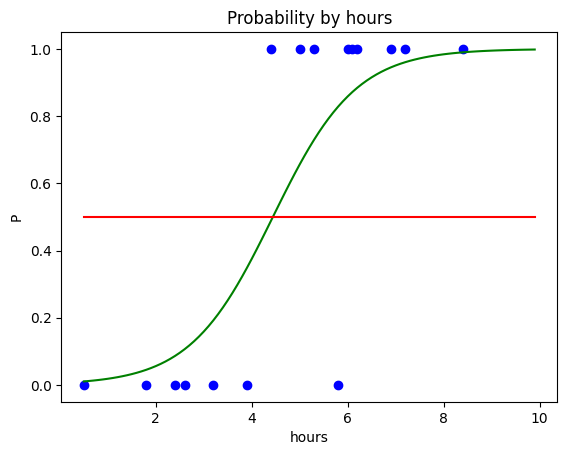

In [53]:
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_range, p, color='green')
plt.plot(X_range, np.full(len(X_range), 0.5), color='red') # X_range 개수만큼 0.5로 가득찬 배열 만들기
plt.title('Probability by hours')
plt.xlabel('hours')
plt.ylabel('P')
plt.show()

## 데이터 시각화 (테스트 세트)


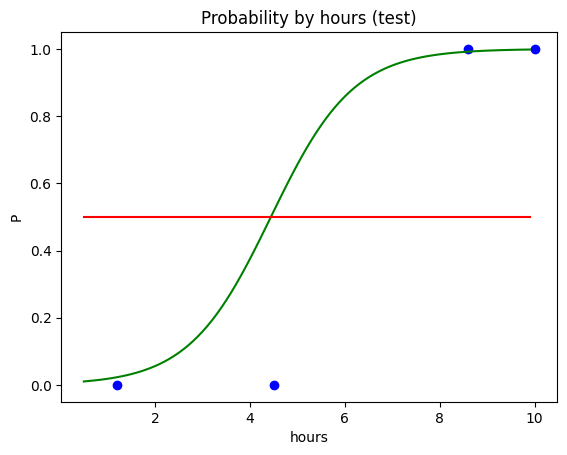

In [54]:
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_range, p, color='green')
plt.plot(X_range, np.full(len(X_range), 0.5), color='red') # X_range 개수만큼 0.5로 가득찬 배열 만들기
plt.title('Probability by hours (test)')
plt.xlabel('hours')
plt.ylabel('P')
plt.show()

In [55]:
classifier.predict_proba([[4.5]]) # 4.5 시간 공부했을 때 확률 (모델에서는 51% 합격 예측, 실제로는 불합격)

array([[0.48307854, 0.51692146]])

# 혼동 행렬 (Confusion Matrix)

In [59]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

'''
[불합격을 예측, 불합격한 개수 | 합격을 예측, 불합격한 개수]
[불합격을 예측, 합격한 개수 | 합격을 예측, 합격한 개수]

[True Negative (TN) | False Positive (FP)]
[False Negative (FN) | True Positive (TP)]
'''

'\n[불합격을 예측, 불합격한 개수 | 합격을 예측, 불합격한 개수]\n[불합격을 예측, 합격한 개수 | 합격을 예측, 합격한 개수]\n\n[True NEgative (TN) | False Positive (FP)]\n[False Negative (FN) | True Positive (TP)]\n'